# WGAN-GP - CelebA Face Generation

This project implements a Wasserstein Generative Adversarial Network with Gradient Penalty (WGAN-GP) to generate synthetic 64×64 RGB face images using the CelebA dataset.

The project extends the earlier DCGAN work by replacing the conventional binary-classification GAN objective with the Wasserstein objective and gradient penalty. The notebook focuses on adversarial training stability, generator and critic design, generated-image progression, latent-space interpolation, and qualitative evaluation.

Runtime: Google Colab
Recommended GPU: NVIDIA Tesla T4
Image resolution: 64 × 64 RGB


In [1]:
# Kaggle API Authentication

from getpass import getpass
import os

kaggle_api_key = getpass("Enter your Kaggle API key: ")

if not kaggle_api_key:
    raise ValueError("Kaggle API key cannot be empty.")

os.environ["KAGGLE_API_KEY"] = kaggle_api_key

!pip install -q -U kaggle

print("Kaggle API configured.")


Enter your Kaggle API key: ··········
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.4 MB/s eta 0:00:00
Kaggle API configured.


## 1. Import Required Libraries

Load TensorFlow, NumPy, Matplotlib, and supporting utilities.


In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))
if tf.config.list_physical_devices("GPU"):
    print("GPU:", tf.config.list_physical_devices("GPU")[0])


TensorFlow Version: 2.20.0
Num GPUs Available: 1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 2. Configure Reproducibility and Training

Set seeds and define the latent dimension, image size, batch size, epochs, optimizer settings, critic update ratio, and gradient-penalty coefficient.

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

LATENT_DIM = 128
IMAGE_SIZE = 64
CHANNELS = 3

BATCH_SIZE = 64
EPOCHS = 50
MAX_TRAIN_IMAGES = 30000

GENERATOR_LEARNING_RATE = 1e-4
CRITIC_LEARNING_RATE = 1e-4

BETA_1 = 0.0
BETA_2 = 0.9

CRITIC_STEPS = 5
GRADIENT_PENALTY_WEIGHT = 10.0

SAMPLE_COUNT = 16
SAMPLE_INTERVAL = 2

print("Latent Dimension:", LATENT_DIM)
print("Image Shape:", (IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
print("Batch Size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Maximum Training Images:", MAX_TRAIN_IMAGES)
print("Generator Learning Rate:", GENERATOR_LEARNING_RATE)
print("Critic Learning Rate:", CRITIC_LEARNING_RATE)
print("Critic Steps:", CRITIC_STEPS)
print("Gradient Penalty Weight:", GRADIENT_PENALTY_WEIGHT)


Latent Dimension: 128
Image Shape: (64, 64, 3)
Batch Size: 64
Epochs: 50
Maximum Training Images: 30000
Generator Learning Rate: 0.0001
Critic Learning Rate: 0.0001
Critic Steps: 5
Gradient Penalty Weight: 10.0


## 3. Load the CelebA Dataset

Download the Kaggle CelebA dataset once, discover its actual extracted folder structure automatically,
and build a TensorFlow dataset from the official CelebA training partition.


In [4]:
from pathlib import Path
import csv

DATA_DIR = Path("/content/celeba")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Download only when CelebA images are not already present.
existing_images = list(DATA_DIR.rglob("*.jpg")) + list(DATA_DIR.rglob("*.JPG"))

if len(existing_images) < 1000:
    !mkdir -p /content/celeba_download
    !kaggle datasets download -d jessicali9530/celeba-dataset -p /content/celeba_download --unzip

    # Copy/expose the extracted dataset under DATA_DIR without assuming
    # a particular nested directory structure.
    download_root = Path("/content/celeba_download")
    extracted_images = list(download_root.rglob("*.jpg")) + list(download_root.rglob("*.JPG"))

    if not extracted_images:
        raise FileNotFoundError("Kaggle download completed, but no JPG images were found.")

    # Keep the extracted Kaggle directory in place and use it as the dataset root.
    DATA_DIR = download_root

# Discover all JPEG images recursively. This avoids relying on a fixed Kaggle folder path.
all_image_files = [
    p for p in DATA_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg"}
]

if not all_image_files:
    raise FileNotFoundError("No CelebA image files were found after extraction.")

image_lookup = {p.name: str(p) for p in all_image_files}

# Locate the official CelebA partition file wherever Kaggle extracted it.
partition_candidates = list(DATA_DIR.rglob("list_eval_partition.csv"))
image_paths = []

if partition_candidates:
    partition_file = partition_candidates[0]

    with open(partition_file, newline="") as file:
        reader = csv.DictReader(file)
        rows = list(reader)

    if not rows or "partition" not in rows[0] or "image_id" not in rows[0]:
        raise ValueError("The CelebA partition file was found but has an unexpected format.")

    for row in rows:
        if row["partition"].strip() == "0":
            image_name = row["image_id"].strip()
            if image_name in image_lookup:
                image_paths.append(image_lookup[image_name])
else:
    # Safe fallback: use the discovered image files if the partition metadata is absent.
    # This keeps the notebook runnable with a Kaggle CelebA mirror that contains the images
    # but not the official partition CSV.
    image_paths = [str(p) for p in sorted(all_image_files)]

if not image_paths:
    raise ValueError("No CelebA training images were found.")

# Shuffle once and use a practical subset so a Colab T4 run remains manageable.
rng = np.random.default_rng(SEED)
rng.shuffle(image_paths)

if MAX_TRAIN_IMAGES is not None:
    image_paths = image_paths[:min(MAX_TRAIN_IMAGES, len(image_paths))]

print("CelebA images available:", len(all_image_files))
print("CelebA images selected for training:", len(image_paths))
if partition_candidates:
    print("Training partition file:", partition_file)
else:
    print("Partition file not found; using discovered CelebA images.")

def load_image_example(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image, channels=3)
    return {"image": image}

celeba_train = (
    tf.data.Dataset.from_tensor_slices(image_paths)
    .shuffle(10000, seed=SEED, reshuffle_each_iteration=True)
    .map(load_image_example, num_parallel_calls=tf.data.AUTOTUNE)
)

print("CelebA TensorFlow dataset created successfully.")


Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [00:35<00:00, 40.1MB/s]

CelebA images available: 202599
CelebA images selected for training: 30000
Training partition file: /content/celeba_download/list_eval_partition.csv
CelebA TensorFlow dataset created successfully.


## 4. Inspect the Dataset

Verify the original image dimensions and display representative face images.


Original Batch Shape: (16, 218, 178, 3)
Original Image Shape: (218, 178, 3)


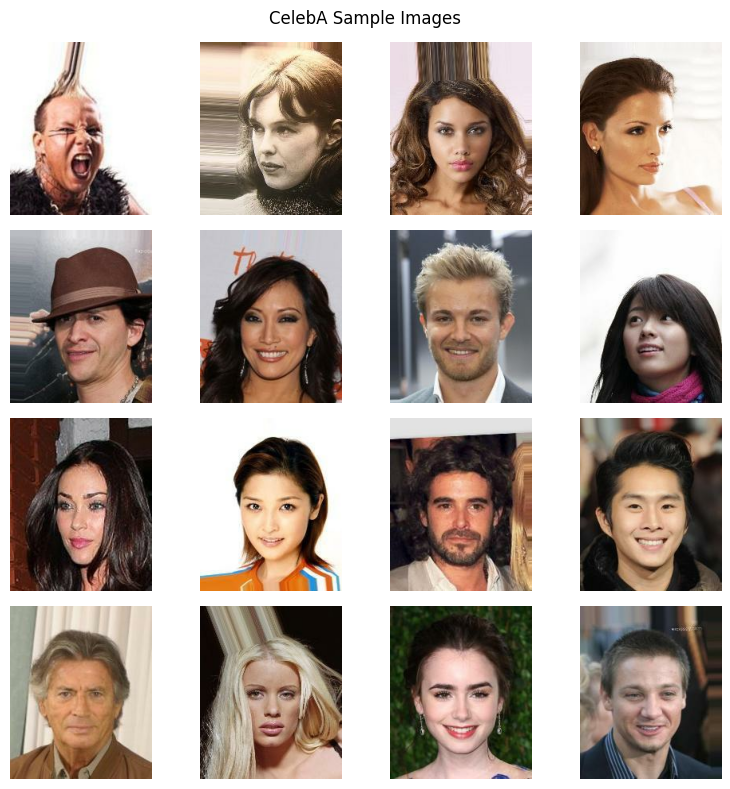

In [5]:
sample_batch = next(
    iter(
        celeba_train.batch(16)
    )
)

sample_images = sample_batch["image"].numpy()

print("Original Batch Shape:", sample_images.shape)
print("Original Image Shape:", sample_images[0].shape)

plt.figure(figsize=(8, 8))

for index in range(16):
    plt.subplot(4, 4, index + 1)
    plt.imshow(sample_images[index])
    plt.axis("off")

plt.suptitle("CelebA Sample Images")
plt.tight_layout()
plt.show()


## 5. Preprocess the Images

Resize faces to 64×64 RGB and normalize pixel values to [-1, 1] for the generator's tanh output.

In [6]:
def preprocess_image(example):
    image = tf.image.resize(
        example["image"],
        [IMAGE_SIZE, IMAGE_SIZE],
        method=tf.image.ResizeMethod.BILINEAR
    )
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image

train_dataset = (
    celeba_train
    .map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .cache()
    .shuffle(10000, seed=SEED, reshuffle_each_iteration=True)
    .batch(
        BATCH_SIZE,
        drop_remainder=True
    )
    .prefetch(tf.data.AUTOTUNE)
)

sample_preprocessed = next(iter(train_dataset))

print("Preprocessed Batch Shape:", sample_preprocessed.shape)
print("Minimum Value:", float(tf.reduce_min(sample_preprocessed)))
print("Maximum Value:", float(tf.reduce_max(sample_preprocessed)))


Preprocessed Batch Shape: (64, 64, 64, 3)
Minimum Value: -1.0
Maximum Value: 1.0


## 6. Build the Generator

Build a convolutional generator that maps latent vectors to 64×64 RGB images.

In [7]:
def build_generator():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(LATENT_DIM,)),
            tf.keras.layers.Dense(4 * 4 * 1024, use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),
            tf.keras.layers.Reshape((4, 4, 1024)),

            tf.keras.layers.Conv2DTranspose(
                512, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),

            tf.keras.layers.Conv2DTranspose(
                256, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),

            tf.keras.layers.Conv2DTranspose(
                128, 4, strides=2, padding="same", use_bias=False
            ),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.ReLU(),

            tf.keras.layers.Conv2DTranspose(
                CHANNELS, 4, strides=2, padding="same", activation="tanh"
            )
        ],
        name="generator"
    )
    return model

generator = build_generator()

test_noise = tf.random.normal([1, LATENT_DIM], seed=SEED)
test_generated = generator(test_noise, training=False)

print("Generator Output Shape:", test_generated.shape)


Generator Output Shape: (1, 64, 64, 3)


## 7. Build the Critic

Build a critic that outputs a real-valued score instead of a probability.

In [8]:
def build_critic():
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(
                shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            ),

            tf.keras.layers.Conv2D(
                64, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Conv2D(
                128, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Conv2D(
                256, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Conv2D(
                512, 4, strides=2, padding="same"
            ),
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.LeakyReLU(negative_slope=0.2),

            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(1)
        ],
        name="critic"
    )
    return model

critic = build_critic()

test_score = critic(test_generated, training=False)
print("Critic Output Shape:", test_score.shape)


Critic Output Shape: (1, 1)


## 8. Inspect the Model Architectures

Print model summaries and verify output shapes.

In [9]:
print("===== GENERATOR =====")
generator.summary()

print("\n===== CRITIC =====")
critic.summary()


===== GENERATOR =====


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 512)      │     8,388,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 3)      │         6,147 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,182,467 (50.29 MB)

 Trainable params: 13,147,907 (50.16 MB)

...

Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 16, 16, 128)    │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 8, 8, 256)      │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 512)      │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 4, 4, 512)      │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,766,529 (10.55 MB)

 Trainable params: 2,766,529 (10.55 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Define the WGAN-GP Objective

Define Wasserstein losses, gradient penalty, and Adam optimizers.

In [10]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=GENERATOR_LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

critic_optimizer = tf.keras.optimizers.Adam(
    learning_rate=CRITIC_LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

def generator_loss(fake_scores):
    return -tf.reduce_mean(fake_scores)

def critic_loss(real_scores, fake_scores):
    return (
        tf.reduce_mean(fake_scores)
        - tf.reduce_mean(real_scores)
    )

def gradient_penalty(real_images, fake_images):
    batch_size = tf.shape(real_images)[0]

    alpha = tf.random.uniform(
        [batch_size, 1, 1, 1],
        0.0,
        1.0
    )

    interpolated = (
        alpha * real_images
        + (1.0 - alpha) * fake_images
    )

    with tf.GradientTape() as tape:
        tape.watch(interpolated)

        interpolated_scores = critic(
            interpolated,
            training=True
        )

    gradients = tape.gradient(
        interpolated_scores,
        interpolated
    )

    gradients = tf.reshape(
        gradients,
        [batch_size, -1]
    )

    gradient_norm = tf.sqrt(
        tf.reduce_sum(
            tf.square(gradients),
            axis=1
        ) + 1e-12
    )

    return tf.reduce_mean(
        tf.square(
            gradient_norm - 1.0
        )
    )

print("WGAN-GP objective and optimizers are ready.")


WGAN-GP objective and optimizers are ready.


## 10. Define the WGAN-GP Training Steps

Implement critic updates, gradient-penalty calculation, and generator updates.

In [11]:
@tf.function
def critic_train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as tape:
        fake_images = generator(noise, training=True)

        real_scores = critic(
            real_images,
            training=True
        )

        fake_scores = critic(
            fake_images,
            training=True
        )

        w_loss = critic_loss(
            real_scores,
            fake_scores
        )

        gp = gradient_penalty(
            real_images,
            fake_images
        )

        total_loss = (
            w_loss
            + GRADIENT_PENALTY_WEIGHT * gp
        )

    gradients = tape.gradient(
        total_loss,
        critic.trainable_variables
    )

    critic_optimizer.apply_gradients(
        zip(
            gradients,
            critic.trainable_variables
        )
    )

    return total_loss, w_loss, gp


@tf.function
def generator_train_step():
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as tape:
        fake_images = generator(
            noise,
            training=True
        )

        fake_scores = critic(
            fake_images,
            training=True
        )

        g_loss = generator_loss(
            fake_scores
        )

    gradients = tape.gradient(
        g_loss,
        generator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients,
            generator.trainable_variables
        )
    )

    return g_loss


fixed_noise = tf.random.normal(
    [SAMPLE_COUNT, LATENT_DIM],
    seed=SEED
)

print("WGAN-GP training functions are ready.")


WGAN-GP training functions are ready.


## 11. Train the WGAN-GP

Train the model and save fixed-noise samples at checkpoints. The configuration uses a practical
CelebA subset and three critic updates per generator update to keep training manageable on a Google Colab T4 GPU.


In [ ]:
progress_epochs = []
progress_images = []

generator_losses = []
critic_losses = []
wasserstein_losses = []
gradient_penalties = []

steps_per_epoch = len(image_paths) // BATCH_SIZE
print("Steps per epoch:", steps_per_epoch)
print("Estimated critic updates per epoch:", steps_per_epoch * CRITIC_STEPS)

for epoch in range(1, EPOCHS + 1):

    epoch_g = []
    epoch_c = []
    epoch_w = []
    epoch_gp = []

    for real_images in train_dataset:

        for _ in range(CRITIC_STEPS):
            c_loss, w_loss, gp = critic_train_step(
                real_images
            )

            epoch_c.append(float(c_loss))
            epoch_w.append(float(w_loss))
            epoch_gp.append(float(gp))

        g_loss = generator_train_step()
        epoch_g.append(float(g_loss))

    mean_g = np.mean(epoch_g)
    mean_c = np.mean(epoch_c)
    mean_w = np.mean(epoch_w)
    mean_gp = np.mean(epoch_gp)

    generator_losses.append(mean_g)
    critic_losses.append(mean_c)
    wasserstein_losses.append(mean_w)
    gradient_penalties.append(mean_gp)

    if (
        epoch == 1
        or epoch % SAMPLE_INTERVAL == 0
        or epoch == EPOCHS
    ):
        generated = generator(
            fixed_noise,
            training=False
        ).numpy()

        progress_epochs.append(epoch)
        progress_images.append(generated)

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Generator Loss: {mean_g:.4f} | "
        f"Critic Loss: {mean_c:.4f} | "
        f"Wasserstein Loss: {mean_w:.4f} | "
        f"Gradient Penalty: {mean_gp:.4f}"
    )

print("WGAN-GP training completed.")


Steps per epoch: 468
Estimated critic updates per epoch: 2340
Epoch 001/50 | Generator Loss: 22.9451 | Critic Loss: -19.9864 | Wasserstein Loss: -25.7069 | Gradient Penalty: 0.5721
Epoch 002/50 | Generator Loss: 3.0989 | Critic Loss: -9.1275 | Wasserstein Loss: -11.1182 | Gradient Penalty: 0.1991
Epoch 003/50 | Generator Loss: -5.2634 | Critic Loss: -6.1667 | Wasserstein Loss: -7.4070 | Gradient Penalty: 0.1240
Epoch 004/50 | Generator Loss: -8.3703 | Critic Loss: -6.1639 | Wasserstein Loss: -7.3530 | Gradient Penalty: 0.1189
Epoch 005/50 | Generator Loss: -5.8990 | Critic Loss: -6.2361 | Wasserstein Loss: -7.4739 | Gradient Penalty: 0.1238
Epoch 006/50 | Generator Loss: -3.6332 | Critic Loss: -6.6426 | Wasserstein Loss: -8.0330 | Gradient Penalty: 0.1390
Epoch 007/50 | Generator Loss: -4.4336 | Critic Loss: -6.3875 | Wasserstein Loss: -7.7247 | Gradient Penalty: 0.1337
Epoch 008/50 | Generator Loss: -2.8693 | Critic Loss: -5.9288 | Wasserstein Loss: -7.2490 | Gradient Penalty: 0.1320


## 12. Visualize Training Progress

Plot generator, critic, Wasserstein, and gradient-penalty curves and show generated faces.

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(
    range(1, EPOCHS + 1),
    generator_losses,
    label="Generator Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    critic_losses,
    label="Critic Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Training Losses")
plt.legend()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(
    range(1, EPOCHS + 1),
    wasserstein_losses,
    label="Wasserstein Loss"
)
plt.plot(
    range(1, EPOCHS + 1),
    gradient_penalties,
    label="Gradient Penalty"
)
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("WGAN-GP Training Components")
plt.legend()
plt.show()

for epoch, images in zip(
    progress_epochs,
    progress_images
):
    plt.figure(figsize=(8, 8))

    for index in range(SAMPLE_COUNT):
        plt.subplot(4, 4, index + 1)

        image = (
            images[index] * 127.5
            + 127.5
        )

        image = np.clip(
            image,
            0,
            255
        ).astype("uint8")

        plt.imshow(image)
        plt.axis("off")

    plt.suptitle(
        f"Generated Faces - Epoch {epoch}"
    )
    plt.tight_layout()
    plt.show()


## 13. Evaluate Final Generated Faces

Generate a larger final image grid for qualitative assessment.

In [ ]:
final_noise = tf.random.normal(
    [64, LATENT_DIM],
    seed=SEED + 100
)

final_images = generator(
    final_noise,
    training=False
).numpy()

plt.figure(figsize=(10, 10))

for index in range(64):
    plt.subplot(8, 8, index + 1)

    image = (
        final_images[index] * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "Final WGAN-GP Generated Faces"
)
plt.tight_layout()
plt.show()

print(
    "Final Generated Tensor Shape:",
    final_images.shape
)


## 14. Latent Space Interpolation

Interpolate between latent vectors to inspect smooth changes in generated faces.

In [ ]:
def interpolate_latent_vectors(
    vector_a,
    vector_b,
    steps=10
):
    alphas = np.linspace(
        0.0,
        1.0,
        steps
    )

    return np.stack(
        [
            (1.0 - alpha) * vector_a
            + alpha * vector_b
            for alpha in alphas
        ]
    )

latent_a = tf.random.normal(
    [LATENT_DIM],
    seed=SEED + 1
)

latent_b = tf.random.normal(
    [LATENT_DIM],
    seed=SEED + 2
)

interpolated_vectors = (
    interpolate_latent_vectors(
        latent_a.numpy(),
        latent_b.numpy(),
        steps=10
    )
)

interpolated_images = generator(
    tf.convert_to_tensor(
        interpolated_vectors,
        dtype=tf.float32
    ),
    training=False
).numpy()

plt.figure(figsize=(15, 6))

for index, image in enumerate(
    interpolated_images
):
    plt.subplot(2, 5, index + 1)

    image = (
        image * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "WGAN-GP Latent Space Interpolation"
)
plt.tight_layout()
plt.show()


## 15. Fixed-Noise Comparison

Generate a repeatable set of final faces from fixed latent vectors.

In [ ]:
comparison_images = generator(
    fixed_noise,
    training=False
).numpy()

plt.figure(figsize=(8, 8))

for index in range(SAMPLE_COUNT):
    plt.subplot(4, 4, index + 1)

    image = (
        comparison_images[index] * 127.5
        + 127.5
    )

    image = np.clip(
        image,
        0,
        255
    ).astype("uint8")

    plt.imshow(image)
    plt.axis("off")

plt.suptitle(
    "Fixed Latent Samples from Final Generator"
)
plt.tight_layout()
plt.show()


## 16. Key Findings



## 17. Conclusion

